# Truck Movement Detection Using Faster R-CNN

### Dataset Used: [Truck Movement Computer Vision Dataset](https://universe.roboflow.com/rf100-vl/truck-movement-qv1up-elxpj-ytsp)

## 1. Import Libraries and check GPU 

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
import cv2
import os
import torch
import torchvision
import numpy as np
import mlflow
from PIL import Image
import matplotlib.pyplot as plt
from mlflow import MlflowClient


from pycocotools.coco import COCO
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import models, transforms
from torchvision.transforms import v2 as T
from torchvision.transforms import ToTensor
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights

In [5]:
# Check GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
 
print(device)

cuda


In [8]:
client = MlflowClient(tracking_uri="http://127.0.0.1:5000")

# Provide experiment description and tags
experiment_description = (
    "This is the truck movement detection project. "
    "This experiment contains the implementation of truck movement detection using Faster R-CNN."
)

experiment_tags = {
    "project_name": "truck_movement_detection",
    "mlflow.note.content": experiment_description,
}

# Create an experiment
client.create_experiment(name="FasterRCNN_TruckDetection", tags=experiment_tags)

'439968466528587794'

## 2. Custom PyTorch Dataset Class for COCO Format

In [10]:
# Custom PyTorch Dataset to load COCO-format annotations and images
class TruckMovementDataset(Dataset):
    # Init function: loads annotation file and prepares list of image IDs
    def __init__(self, image_dir, annotation_path, transforms=None):
        self.image_dir = image_dir
        self.coco = COCO(annotation_path)
        self.image_ids = list(self.coco.imgs.keys())
        self.transforms = transforms
 
    # Returns total number of images
    def __len__(self):
        return len(self.image_ids)
 
    # Fetches a single image and its annotations
    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image_info = self.coco.loadImgs(image_id)[0]
        image_path = os.path.join(self.image_dir, image_info['file_name'])
        image = Image.open(image_path).convert("RGB")
 
        # Load all annotations for this image
        annotation_ids = self.coco.getAnnIds(imgIds=image_id)
        annotations = self.coco.loadAnns(annotation_ids)
 
        # Extract bounding boxes and labels from annotations
        boxes = []
        labels = []
        for obj in annotations:
            xmin, ymin, width, height = obj['bbox']
            xmax = xmin + width
            ymax = ymin + height
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(obj['category_id'])

        # Convert annotations to PyTorch tensors
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        area = torch.as_tensor([obj['area'] for obj in annotations],    dtype=torch.float32)
        iscrowd = torch.as_tensor([obj.get('iscrowd', 0) for obj in annotations], dtype=torch.int64)
 
        # Package everything into a target dictionary
        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": image_id,
            "area": area,
            "iscrowd": iscrowd
        }
 
        # Apply transforms if any were passed
        if self.transforms:
            image = self.transforms(image)
 
        return image, target

In [11]:
def collate_fn(batch):
    return tuple(zip(*batch))

## 3. Create Train and Validation sets

In [12]:
# Transform PIL image --> PyTorch tensor
def get_transform():
    return ToTensor()
 
# Load training dataset
train_dataset = TruckMovementDataset(
    image_dir="truck-movement/train", 
    annotation_path="truck-movement/train/_annotations.coco.json",
    transforms=get_transform()
)
 
# Load validation dataset
val_dataset = TruckMovementDataset(
    image_dir="truck-movement/valid",
    annotation_path="truck-movement/valid/_annotations.coco.json",
    transforms=get_transform()
)
 
# Load dataset with DataLoaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


## 4. Display Sample Images from the DataLoader Objects

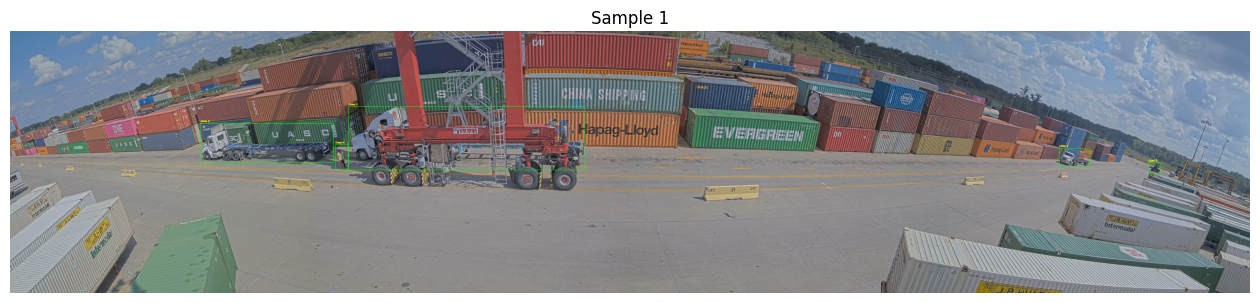

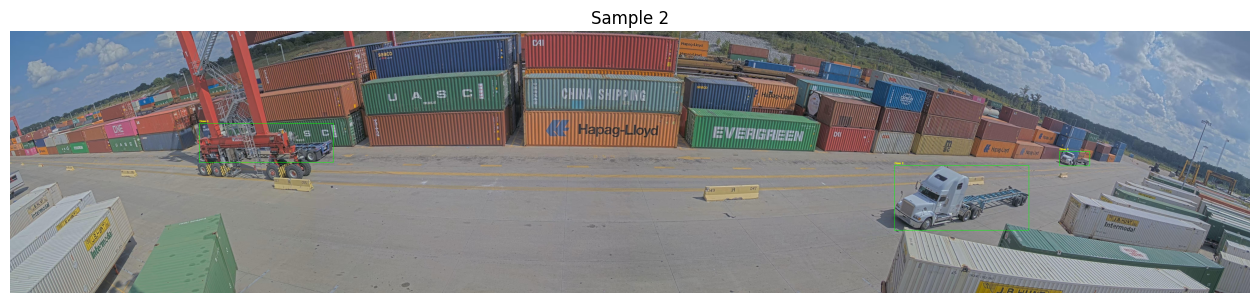

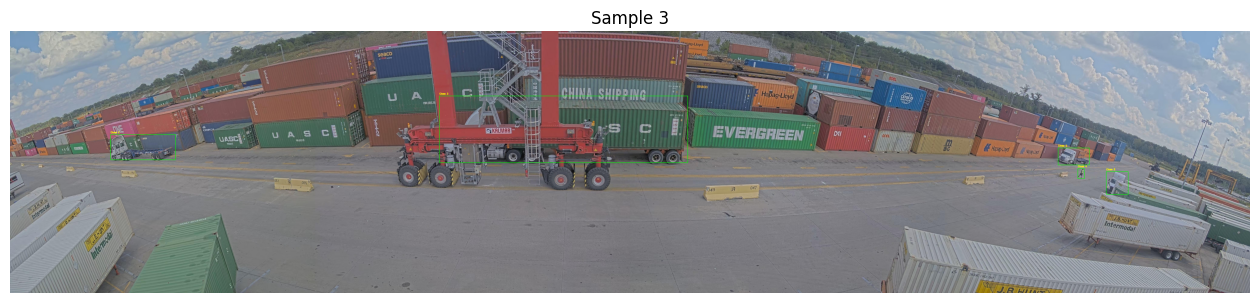

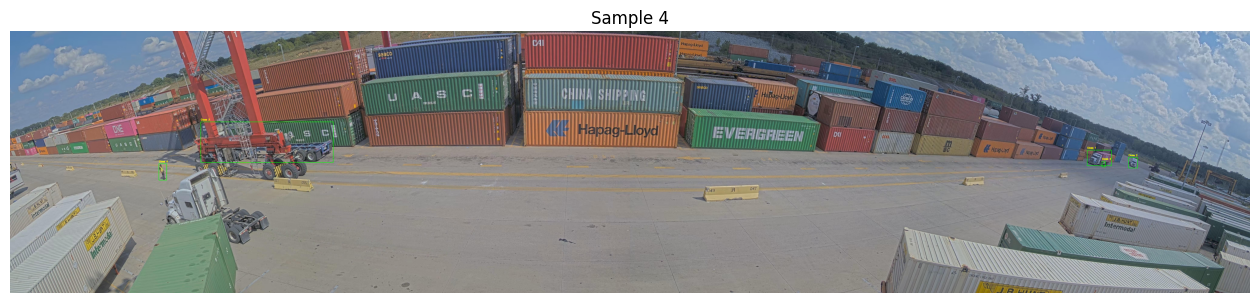

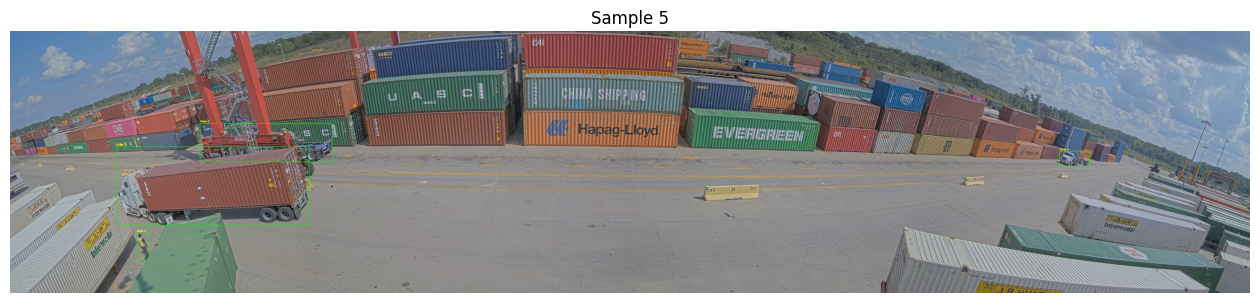

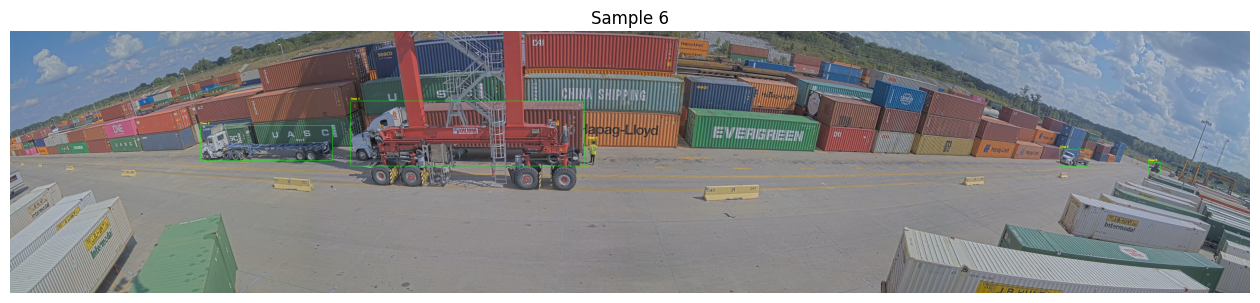

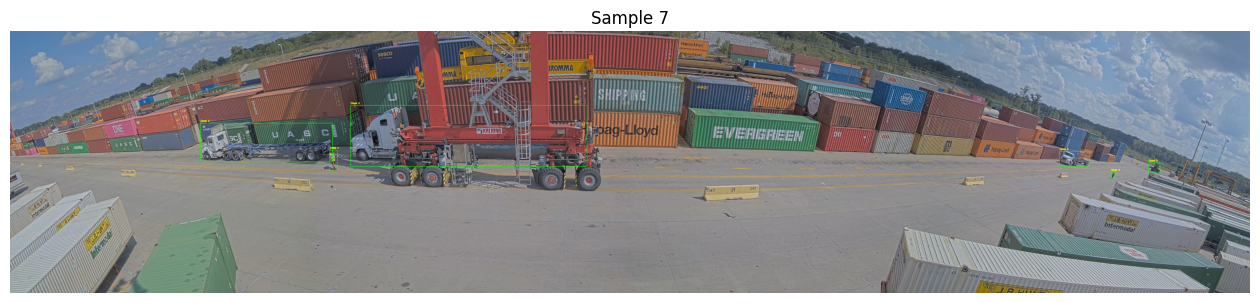

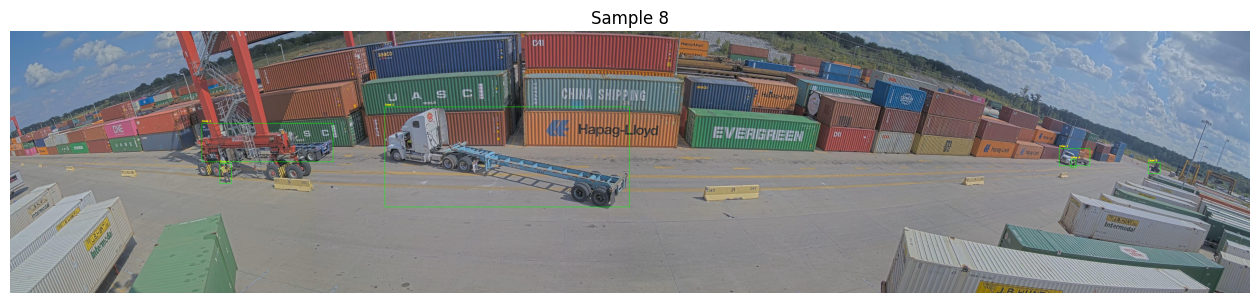

In [13]:
# Get one batch
images, targets = next(iter(train_loader))
 
# loop through one batch and draw bounding boxes and labels
for i in range(len(images)):
    # CxHxW --> HxWxC
    image = images[i].permute(1, 2, 0).numpy()   
    # Rescale
    image = (image * 255).astype(np.uint8)   
    # Convert RGB to BGR
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
     
    # get bounding box coordinates and labels
    boxes = targets[i]['boxes']
    labels = targets[i]['labels']
 
    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = map(int, box.tolist())
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(image, f"Class {label.item()}", (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)
 
    # Show image with bboxes using matplotlib
    plt.figure(figsize=(16, 12))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Sample {i + 1}")
    plt.show()

## 5.  Load a Pre-trained Faster R-CNN Model

In [14]:
# Load a pre-trained Faster R-CNN model with ResNet50 backbone and FPN
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
 
# Number of classes in the dataset (including background)
# +1 for bg class
num_classes = 6
 
# Number of input features for the classifier head
in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
 
# Move the model to the GPU for faster training
model.to(device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

## 6. Adjust Training Parameters

In [15]:
# Get parameters that require gradients (the model's trainable parameters)
params = [p for p in model.parameters() if p.requires_grad]
 
# Define the optimizer SGD(Stochastic Gradient Descent) 
optimizer = torch.optim.SGD(params, lr=0.005,
                            momentum=0.9, weight_decay=0.0005)

## 7. Get Helper Functions

In [21]:
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/engine.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/utils.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/coco_utils.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/coco_eval.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/transforms.py")

--2025-11-05 10:38:10--  https://raw.githubusercontent.com/pytorch/vision/main/references/detection/engine.py
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8003::154, 2606:50c0:8000::154, 2606:50c0:8001::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8003::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4063 (4.0K) [text/plain]
Saving to: ‘engine.py’

     0K ...                                                   100% 39.3M=0s

2025-11-05 10:38:10 (39.3 MB/s) - ‘engine.py’ saved [4063/4063]

--2025-11-05 10:38:10--  https://raw.githubusercontent.com/pytorch/vision/main/references/detection/utils.py
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8003::154, 2606:50c0:8001::154, 2606:50c0:8000::154, ...
Connecting to raw.githubusercontent.com (r

0

## 8. Model Training 

In [16]:
# Use the fluent API to set the tracking uri and the active experiment
mlflow.set_tracking_uri("http://127.0.0.1:5000/")

In [17]:
# Sets the current active experiment to the "Plant_Disease_Detection" experiment and returns the Experiment metadata
faster_rcnn_training = mlflow.set_experiment("FasterRCNN_TruckDetection")

# Define a run name for this iteration of training.
# If this is not set, a unique name will be auto-generated for your run.
run_name = "FasterRCNN_TruckDetection_Run"

In [18]:
mlflow.pytorch.autolog()

In [19]:
from engine import train_one_epoch, evaluate
 
# Number of epochs for training
num_epochs = 25

with mlflow.start_run(run_name=run_name) as run:
    
    # Loop through each epoch
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}")
     
        # Train the model for one epoch, printing status every 25 iterations
        train_one_epoch(model, optimizer, train_loader, device, epoch, print_freq=25)  # Using train_loader for training
     
        # Evaluate the model only on the validation dataset, not training
        evaluate(model, val_loader, device=device)  # Using val_loader for evaluation
     
        # save the model after each epoch
        torch.save(model.state_dict(), f"models/truck_movement_detection_epoch_{epoch + 1}.pth")


Epoch 1/25
Epoch: [0]  [ 0/90]  eta: 0:02:50  lr: 0.000061  loss: 2.6448 (2.6448)  loss_classifier: 1.9219 (1.9219)  loss_box_reg: 0.2487 (0.2487)  loss_objectness: 0.1271 (0.1271)  loss_rpn_box_reg: 0.3471 (0.3471)  time: 1.8902  data: 0.6931  max mem: 4414
Epoch: [0]  [25/90]  eta: 0:01:36  lr: 0.001464  loss: 1.1872 (1.4926)  loss_classifier: 0.5669 (0.8847)  loss_box_reg: 0.3744 (0.3372)  loss_objectness: 0.0825 (0.1024)  loss_rpn_box_reg: 0.1351 (0.1683)  time: 1.4560  data: 0.7539  max mem: 4573
Epoch: [0]  [50/90]  eta: 0:00:57  lr: 0.002867  loss: 0.7934 (1.1655)  loss_classifier: 0.2842 (0.6049)  loss_box_reg: 0.3428 (0.3462)  loss_objectness: 0.0413 (0.0770)  loss_rpn_box_reg: 0.1048 (0.1374)  time: 1.4021  data: 0.7038  max mem: 4573
Epoch: [0]  [75/90]  eta: 0:00:21  lr: 0.004270  loss: 0.6552 (1.0153)  loss_classifier: 0.2199 (0.4809)  loss_box_reg: 0.3473 (0.3500)  loss_objectness: 0.0263 (0.0645)  loss_rpn_box_reg: 0.0746 (0.1200)  time: 1.4003  data: 0.7028  max mem: 4

## 10. Model Prediction 

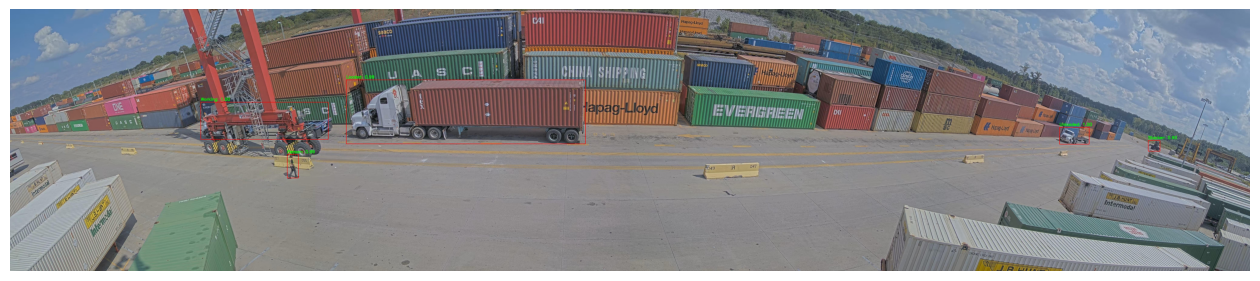

In [29]:
# class names
label_list= ["__background__", "Loaded", 
             "Unloaded", "Working", 
             "Person", "Stacker"]
 
# Number of classes (include background)
num_classes = 6
 
# Load the same model 
model = models.detection.fasterrcnn_resnet50_fpn(weights=None, num_classes=num_classes)
 
# Load trained Faster R-CNN model
model.load_state_dict(torch.load(r"models/truck_movement_detection_epoch_10.pth"))
model.eval()
 
# Load image with OpenCV and convert to RGB
# img_path = r"truck-movement/test/20211007_143316_A95A_B8A44F18664E_mp4-214_jpg.rf.5edc41aa19fbcea37a12450307a1ec14.jpg"
img_path = r"truck-movement/test/20211007_140523_6A9D_B8A44F18664E_mp4-528_jpg.rf.144d18e8fe2990edae8e3235a9873d49.jpg"
# img_path = "/home/aashish/Downloads/NWSA.286-1_0.jpg"
# img_path = "/home/aashish/Downloads/istockphoto-1124695331-612x612.jpg"
image_bgr = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
image_pil = Image.fromarray(image_rgb)
 
 
transform = transforms.Compose([transforms.ToTensor()])
image_tensor = transform(image_pil).unsqueeze(0)
 
# Inference
with torch.no_grad():
    predictions = model(image_tensor)
 
# detection data
boxes = predictions[0]['boxes']
labels = predictions[0]['labels']
scores = predictions[0]['scores']
 
"""
Higher threshold give you more accurate detections, 
but number of predictions is reduced; there is a simple trade-off
"""
threshold = 0.8
for i in range(len(boxes)):
    if scores[i] > threshold:
        box = boxes[i].cpu().numpy().astype(int)
        label = label_list[labels[i]]
        score = scores[i].item()
 
         
        text = f"{label}: {score:.2f}"
        cv2.putText(image_bgr, text, (box[0], box[1] - 10), cv2.FONT_HERSHEY_SIMPLEX,
                    0.9, (0, 255, 0), 2, cv2.LINE_AA)
 
        # Draw bbox and label
        cv2.rectangle(image_bgr, (box[0], box[1]), (box[2], box[3]), (0, 0, 255), 2)
 
 
# Convert BGR --> RGB
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
 
# Show image with larger figure size
plt.figure(figsize=(16, 12)) 
plt.imshow(image_rgb)
plt.axis('off')
plt.show()